In [1]:
# Cell 1: Load everything we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, precision_recall_curve, 
                             average_precision_score, make_scorer, recall_score)
import xgboost as xgb
from imblearn.over_sampling import SMOTE

print("✓ All libraries loaded!")

✓ All libraries loaded!


In [2]:
# Cell 2: Load and prepare data (quick recap)
print("Loading data...")
df = pd.read_csv('../data/creditcard.csv')

# Create features (from Phase 2)
df['Hour'] = (df['Time'] / 3600) % 24
df['Day'] = (df['Time'] / 86400).astype(int)
df['Is_Night'] = ((df['Hour'] >= 22) | (df['Hour'] <= 6)).astype(int)
df['Amount_Log'] = np.log1p(df['Amount'])
df['Is_Round_Amount'] = (df['Amount'] % 10 == 0).astype(int)

v_columns = [col for col in df.columns if col.startswith('V')]
df['V_sum'] = df[v_columns].sum(axis=1)
df['V_mean'] = df[v_columns].mean(axis=1)
df['V_std'] = df[v_columns].std(axis=1)
df['V_max'] = df[v_columns].max(axis=1)
df['V_min'] = df[v_columns].min(axis=1)

feature_columns = (
    [col for col in df.columns if col.startswith('V')] +
    ['Amount', 'Amount_Log', 'Hour', 'Day', 'Is_Night', 
     'Is_Round_Amount', 'V_sum', 'V_mean', 'V_std', 'V_max', 'V_min']
)

X = df[feature_columns]
y = df['Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"✓ Data prepared!")
print(f"  Training samples: {len(X_train_balanced):,}")
print(f"  Test samples: {len(X_test):,}")
print(f"  Features: {len(feature_columns)}")

Loading data...
✓ Data prepared!
  Training samples: 454,902
  Test samples: 56,962
  Features: 44


In [4]:
# Cell 3: Grid Search - Try all combinations
from sklearn.model_selection import GridSearchCV

print("="*60)
print("HYPERPARAMETER TUNING WITH GRID SEARCH")
print("="*60)

# Define parameter grid to search
param_grid = {
    'max_depth': [3, 5, 7],              # Tree depth
    'learning_rate': [0.01, 0.1, 0.3],   # Learning speed
    'n_estimators': [50, 100, 200],      # Number of trees
    'min_child_weight': [1, 3, 5],       # Minimum samples in leaf
    'subsample': [0.8, 1.0],             # Fraction of samples per tree
    'colsample_bytree': [0.8, 1.0]       # Fraction of features per tree
}

print(f"\nParameter combinations to test: {3*3*3*3*2*2} = 324 combinations")
print("This might take 10-15 minutes...\n")

# Calculate scale_pos_weight
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Create base model
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr'
)

# Create custom scorer (we care about recall!)
recall_scorer = make_scorer(recall_score)

# Grid Search with Cross-Validation
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring=recall_scorer,      # Optimize for recall
    cv=3,                        # 3-fold cross-validation
    verbose=2,                   # Show progress
    n_jobs=-1                    # Use all CPU cores
)

print("Starting Grid Search...")
grid_search.fit(X_train_balanced, y_train_balanced)

print("\n" + "="*60)
print("✓ Grid Search Complete!")
print("="*60)
print(f"\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest Cross-Validation Recall: {grid_search.best_score_:.4f}")
# ```

# **What's happening here?**

# 1. **Grid Search** tries every combination of parameters
# 2. **Cross-Validation** (cv=3) splits training data into 3 parts:
# ```
#    Fold 1: Train on [Part 2, Part 3], Test on [Part 1]
#    Fold 2: Train on [Part 1, Part 3], Test on [Part 2]
#    Fold 3: Train on [Part 1, Part 2], Test on [Part 3]

HYPERPARAMETER TUNING WITH GRID SEARCH

Parameter combinations to test: 324 = 324 combinations
This might take 10-15 minutes...

Starting Grid Search...
Fitting 3 folds for each of 324 candidates, totalling 972 fits

✓ Grid Search Complete!

Best Parameters:
  colsample_bytree: 0.8
  learning_rate: 0.01
  max_depth: 3
  min_child_weight: 1
  n_estimators: 50
  subsample: 0.8

Best Cross-Validation Recall: 1.0000


In [5]:
# Cell 3 Alternative: Randomized Search (faster!)
from sklearn.model_selection import RandomizedSearchCV

print("="*60)
print("HYPERPARAMETER TUNING WITH RANDOMIZED SEARCH")
print("="*60)

# Define parameter distributions
param_distributions = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'n_estimators': [50, 100, 150, 200, 300],
    'min_child_weight': [1, 2, 3, 4, 5],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4]
}

print(f"\nWill test 50 random combinations (instead of all possible)")
print("Estimated time: 5-7 minutes\n")

# Calculate scale_pos_weight
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Create base model
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr'
)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=50,              # Try 50 random combinations
    scoring=make_scorer(recall_score),
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Starting Randomized Search...")
random_search.fit(X_train_balanced, y_train_balanced)

print("\n" + "="*60)
print("✓ Randomized Search Complete!")
print("="*60)
print(f"\nBest Parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest Cross-Validation Recall: {random_search.best_score_:.4f}")

# Use this for rest of the notebook
best_model = random_search.best_estimator_

HYPERPARAMETER TUNING WITH RANDOMIZED SEARCH

Will test 50 random combinations (instead of all possible)
Estimated time: 5-7 minutes

Starting Randomized Search...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

✓ Randomized Search Complete!

Best Parameters:
  subsample: 0.6
  n_estimators: 300
  min_child_weight: 2
  max_depth: 3
  learning_rate: 0.05
  gamma: 0.4
  colsample_bytree: 0.6

Best Cross-Validation Recall: 1.0000


Evaluating tuned model on test set...

TUNED MODEL PERFORMANCE
Precision: 0.0017 (0.17%)
Recall:    1.0000 (100.00%)
F1-Score:  0.0035
ROC-AUC:   0.9080


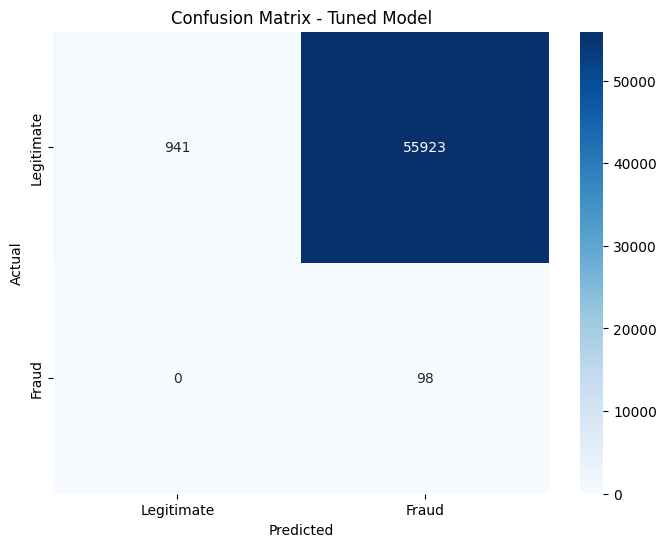


Confusion Matrix:
  True Negatives:  941
  False Positives: 55,923
  False Negatives: 0 ← Missed frauds
  True Positives:  98 ← Caught frauds


In [6]:
# Cell 4: Evaluate tuned model
print("Evaluating tuned model on test set...")

# Get best model (use grid_search or random_search depending on which you ran)
best_model = grid_search.best_estimator_  # or random_search.best_estimator_

# Predict
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*60)
print("TUNED MODEL PERFORMANCE")
print("="*60)
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Tuned Model')
plt.show()

print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0,0]:,}")
print(f"  False Positives: {cm[0,1]:,}")
print(f"  False Negatives: {cm[1,0]:,} ← Missed frauds")
print(f"  True Positives:  {cm[1,1]:,} ← Caught frauds")

CROSS-VALIDATION - TESTING MODEL ROBUSTNESS

Performing 5-fold cross-validation...
This will take a few minutes...

CROSS-VALIDATION RESULTS

RECALL:
  Train: 0.9226 (+/- 0.0116)
  Test:  0.8707 (+/- 0.0864)

PRECISION:
  Train: 0.1195 (+/- 0.0649)
  Test:  0.1121 (+/- 0.0625)

F1:
  Train: 0.2099 (+/- 0.1000)
  Test:  0.1971 (+/- 0.0964)

ROC_AUC:
  Train: 0.9905 (+/- 0.0028)
  Test:  0.9787 (+/- 0.0092)


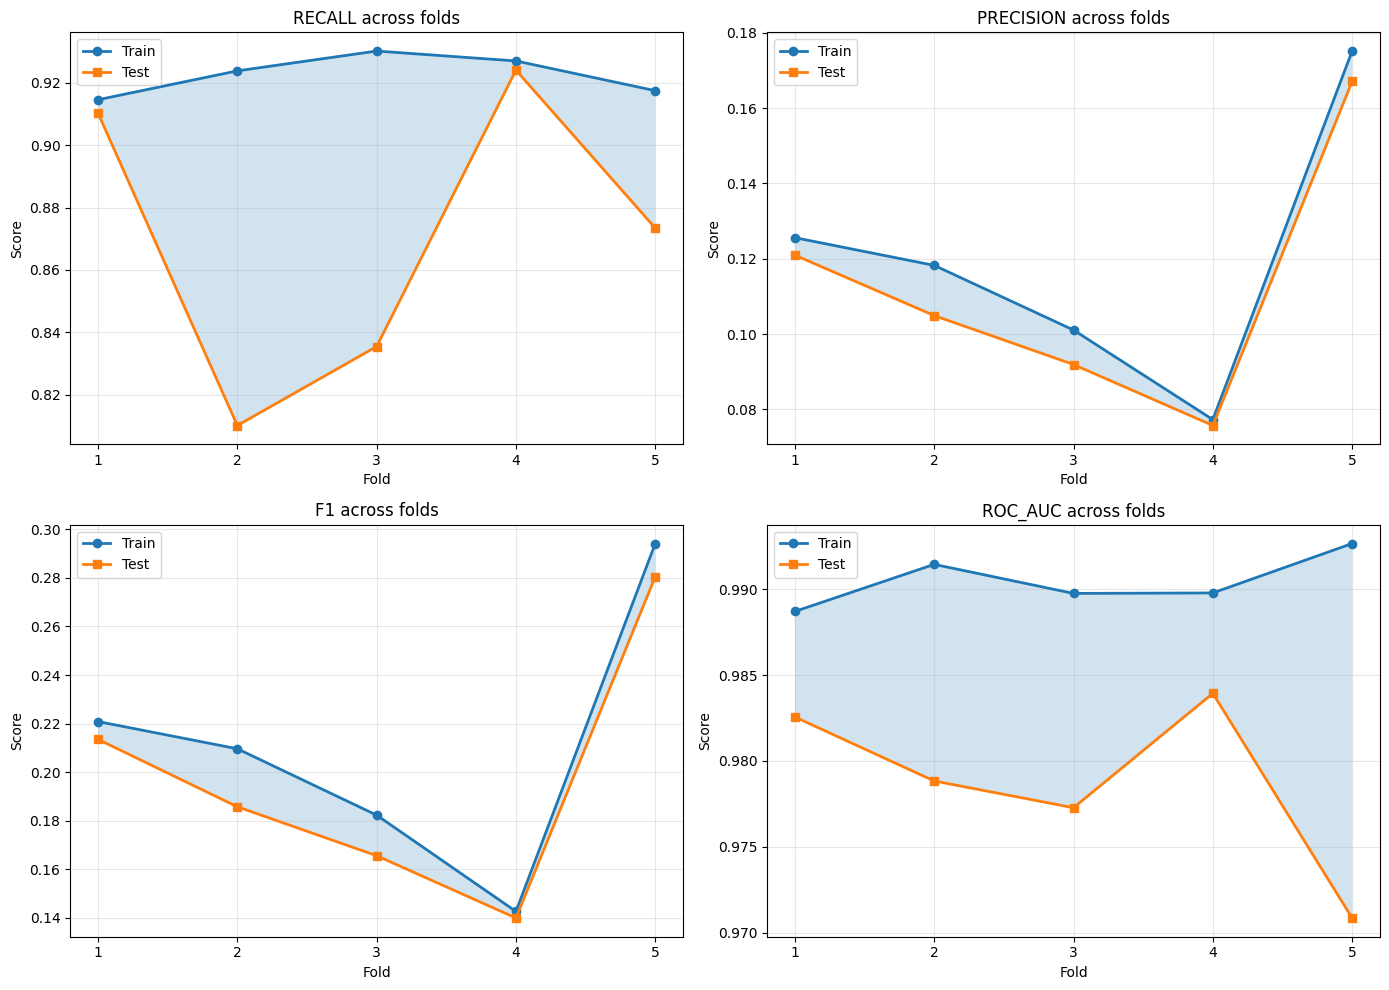

In [7]:
# Cell 5: Perform k-fold cross-validation
from sklearn.model_selection import StratifiedKFold, cross_validate

print("="*60)
print("CROSS-VALIDATION - TESTING MODEL ROBUSTNESS")
print("="*60)

# Create stratified k-fold (maintains fraud ratio in each fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define multiple scoring metrics
scoring = {
    'recall': make_scorer(recall_score),
    'precision': make_scorer(precision_score),
    'f1': make_scorer(f1_score),
    'roc_auc': 'roc_auc'
}

print("\nPerforming 5-fold cross-validation...")
print("This will take a few minutes...\n")

# Perform cross-validation
cv_results = cross_validate(
    best_model,
    X_train_scaled,  # Use original training data (not SMOTE)
    y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# Display results
print("="*60)
print("CROSS-VALIDATION RESULTS")
print("="*60)

metrics = ['recall', 'precision', 'f1', 'roc_auc']
for metric in metrics:
    train_scores = cv_results[f'train_{metric}']
    test_scores = cv_results[f'test_{metric}']
    
    print(f"\n{metric.upper()}:")
    print(f"  Train: {train_scores.mean():.4f} (+/- {train_scores.std()*2:.4f})")
    print(f"  Test:  {test_scores.mean():.4f} (+/- {test_scores.std()*2:.4f})")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, metric in enumerate(metrics):
    train_scores = cv_results[f'train_{metric}']
    test_scores = cv_results[f'test_{metric}']
    
    x = np.arange(1, 6)
    axes[idx].plot(x, train_scores, 'o-', label='Train', linewidth=2)
    axes[idx].plot(x, test_scores, 's-', label='Test', linewidth=2)
    axes[idx].fill_between(x, train_scores, test_scores, alpha=0.2)
    axes[idx].set_xlabel('Fold')
    axes[idx].set_ylabel('Score')
    axes[idx].set_title(f'{metric.upper()} across folds')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)
    axes[idx].set_xticks(x)

plt.tight_layout()
plt.show()
# ```

# **What to look for:**
# - **Consistent scores** across folds = robust model
# - **Large gap** between train and test = overfitting
# - **Similar train and test** = good generalization

# ---

# ## ⚖️ **LESSON 3.3: Threshold Optimization**

# ### **Understanding Decision Thresholds**

# **Current behavior:**
# ```
# Model outputs: 0.51 probability of fraud → Predicts: FRAUD
# Model outputs: 0.49 probability of fraud → Predicts: LEGITIMATE

THRESHOLD OPTIMIZATION

Diagnostic Check:
Test set size: 56962
Test set frauds: 98
Test set fraud rate: 0.172%

Predicted probabilities:
  Min: 0.4586
  Max: 0.9269
  Mean: 0.8132
  Median: 0.9041

Predictions with probability > 0.5: 56,021 (98.35%)

Testing 18 different thresholds...

Sample of Results (every 3rd threshold):
 threshold  precision   recall       f1  fp_rate  n_predicted_fraud
      0.05   0.001720 1.000000 0.003435 1.000000              56962
      0.20   0.001720 1.000000 0.003435 1.000000              56962
      0.35   0.001720 1.000000 0.003435 1.000000              56962
      0.50   0.001749 1.000000 0.003493 0.983452              56021
      0.65   0.002314 0.989796 0.004617 0.735509              41921
      0.80   0.002356 0.989796 0.004701 0.722232              41166


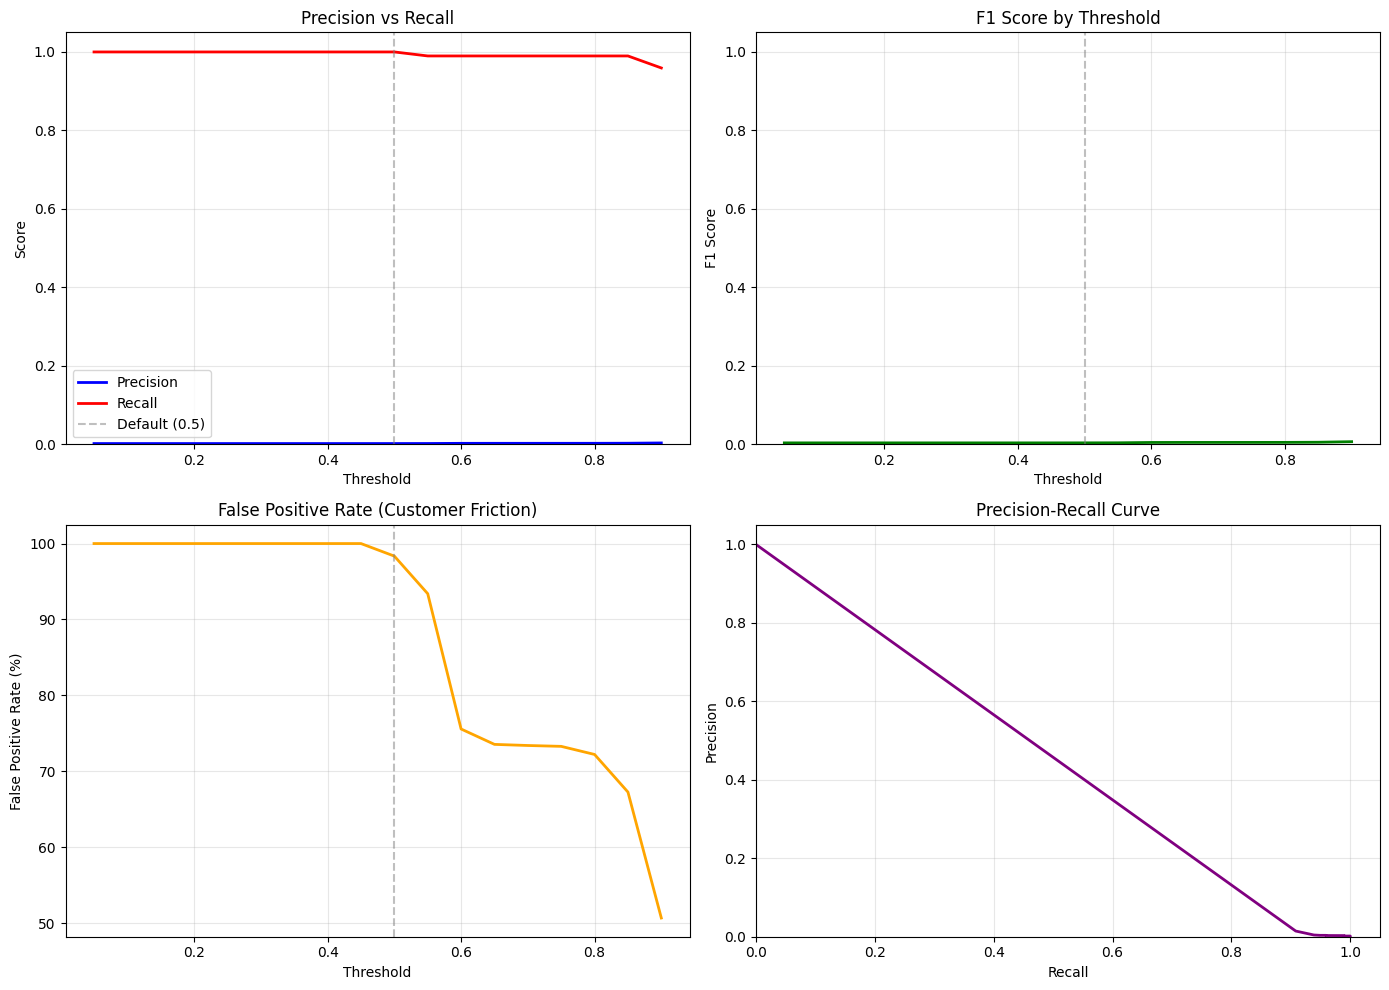


RECOMMENDED THRESHOLDS

1. Best F1-Score:
   Threshold: 0.90
   Precision: 0.0033
   Recall:    0.9592
   F1:        0.0065
   Predicted frauds: 28916

2. High Recall (catch ≥95% of frauds):
   Threshold: 0.90
   Precision: 0.0033
   Recall:    0.9592
   FP Rate:   50.69%
   Predicted frauds: 28916

3. Balanced (default threshold = 0.5):
   Threshold: 0.50
   Precision: 0.0017
   Recall:    1.0000
   F1:        0.0035
   Predicted frauds: 56021

4. High Precision: No threshold achieves ≥80% precision

RECOMMENDATION FOR PRODUCTION:
Use threshold that maximizes F1-Score for balanced performance
OR adjust based on business cost of false positives vs false negatives


In [9]:
# Cell 6 (FIXED): Analyze different thresholds
print("="*60)
print("THRESHOLD OPTIMIZATION")
print("="*60)

# First, let's check if the model is working correctly
print("\nDiagnostic Check:")
print(f"Test set size: {len(y_test)}")
print(f"Test set frauds: {y_test.sum()}")
print(f"Test set fraud rate: {y_test.mean()*100:.3f}%")

# Get probabilities
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nPredicted probabilities:")
print(f"  Min: {y_pred_proba.min():.4f}")
print(f"  Max: {y_pred_proba.max():.4f}")
print(f"  Mean: {y_pred_proba.mean():.4f}")
print(f"  Median: {np.median(y_pred_proba):.4f}")

# Check prediction distribution
high_prob_count = (y_pred_proba > 0.5).sum()
print(f"\nPredictions with probability > 0.5: {high_prob_count:,} ({high_prob_count/len(y_pred_proba)*100:.2f}%)")

# Try different thresholds (FIXED: include more granular steps and 0.5)
thresholds = np.concatenate([
    np.arange(0.05, 0.5, 0.05),   # 0.05 to 0.45
    [0.5],                         # Explicitly include 0.5
    np.arange(0.55, 0.95, 0.05)   # 0.55 to 0.90
])

results = []

print(f"\nTesting {len(thresholds)} different thresholds...")

for threshold in thresholds:
    y_pred_thresh = (y_pred_proba >= threshold).astype(int)
    
    # Count predictions
    n_predicted_fraud = y_pred_thresh.sum()
    
    # Calculate metrics (handle edge cases)
    if n_predicted_fraud > 0:
        precision = precision_score(y_test, y_pred_thresh, zero_division=0)
    else:
        precision = 0.0
    
    recall = recall_score(y_test, y_pred_thresh, zero_division=0)
    
    if precision + recall > 0:
        f1 = 2 * (precision * recall) / (precision + recall)
    else:
        f1 = 0.0
    
    # Calculate false positives
    cm = confusion_matrix(y_test, y_pred_thresh)
    
    tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    
    # False positive rate
    fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'fp_rate': fp_rate,
        'n_predicted_fraud': n_predicted_fraud,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn
    })

results_df = pd.DataFrame(results)

# Display sample of results
print("\n" + "="*60)
print("Sample of Results (every 3rd threshold):")
print("="*60)
display_df = results_df.iloc[::3][['threshold', 'precision', 'recall', 'f1', 'fp_rate', 'n_predicted_fraud']]
print(display_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Precision vs Recall
axes[0, 0].plot(results_df['threshold'], results_df['precision'], 'b-', label='Precision', linewidth=2)
axes[0, 0].plot(results_df['threshold'], results_df['recall'], 'r-', label='Recall', linewidth=2)
axes[0, 0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[0, 0].set_xlabel('Threshold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Precision vs Recall')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_ylim([0, 1.05])

# F1 Score
axes[0, 1].plot(results_df['threshold'], results_df['f1'], 'g-', linewidth=2)
axes[0, 1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Threshold')
axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].set_title('F1 Score by Threshold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_ylim([0, 1.05])

# False Positive Rate
axes[1, 0].plot(results_df['threshold'], results_df['fp_rate']*100, 'orange', linewidth=2)
axes[1, 0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Threshold')
axes[1, 0].set_ylabel('False Positive Rate (%)')
axes[1, 0].set_title('False Positive Rate (Customer Friction)')
axes[1, 0].grid(alpha=0.3)

# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
precision_curve, recall_curve, thresholds_curve = precision_recall_curve(y_test, y_pred_proba)
axes[1, 1].plot(recall_curve, precision_curve, 'purple', linewidth=2)
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision-Recall Curve')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xlim([0, 1.05])
axes[1, 1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# Find optimal thresholds based on different criteria
print("\n" + "="*60)
print("RECOMMENDED THRESHOLDS")
print("="*60)

# 1. Best F1-Score
best_f1_idx = results_df['f1'].idxmax()
print(f"\n1. Best F1-Score:")
print(f"   Threshold: {results_df.loc[best_f1_idx, 'threshold']:.2f}")
print(f"   Precision: {results_df.loc[best_f1_idx, 'precision']:.4f}")
print(f"   Recall:    {results_df.loc[best_f1_idx, 'recall']:.4f}")
print(f"   F1:        {results_df.loc[best_f1_idx, 'f1']:.4f}")
print(f"   Predicted frauds: {results_df.loc[best_f1_idx, 'n_predicted_fraud']:.0f}")

# 2. High Recall (catch most frauds)
high_recall_df = results_df[results_df['recall'] >= 0.95]
if len(high_recall_df) > 0:
    # Among high recall, choose best precision
    best_high_recall_idx = high_recall_df['precision'].idxmax()
    high_recall_thresh = results_df.loc[best_high_recall_idx]
    
    print(f"\n2. High Recall (catch ≥95% of frauds):")
    print(f"   Threshold: {high_recall_thresh['threshold']:.2f}")
    print(f"   Precision: {high_recall_thresh['precision']:.4f}")
    print(f"   Recall:    {high_recall_thresh['recall']:.4f}")
    print(f"   FP Rate:   {high_recall_thresh['fp_rate']*100:.2f}%")
    print(f"   Predicted frauds: {high_recall_thresh['n_predicted_fraud']:.0f}")
else:
    print(f"\n2. High Recall: No threshold achieves ≥95% recall")
    best_recall_idx = results_df['recall'].idxmax()
    print(f"   Best recall achieved: {results_df.loc[best_recall_idx, 'recall']:.4f} at threshold {results_df.loc[best_recall_idx, 'threshold']:.2f}")

# 3. Balanced (default 0.5)
print(f"\n3. Balanced (default threshold = 0.5):")
balanced_thresh = results_df[results_df['threshold'] == 0.5]

if len(balanced_thresh) > 0:
    balanced_thresh = balanced_thresh.iloc[0]
    print(f"   Threshold: 0.50")
    print(f"   Precision: {balanced_thresh['precision']:.4f}")
    print(f"   Recall:    {balanced_thresh['recall']:.4f}")
    print(f"   F1:        {balanced_thresh['f1']:.4f}")
    print(f"   Predicted frauds: {balanced_thresh['n_predicted_fraud']:.0f}")
else:
    print(f"   Threshold 0.5 not found in results")

# 4. High Precision (minimize false alarms)
high_precision_df = results_df[results_df['precision'] >= 0.8]
if len(high_precision_df) > 0:
    best_high_precision_idx = high_precision_df['recall'].idxmax()
    high_precision_thresh = results_df.loc[best_high_precision_idx]
    
    print(f"\n4. High Precision (≥80% precision):")
    print(f"   Threshold: {high_precision_thresh['threshold']:.2f}")
    print(f"   Precision: {high_precision_thresh['precision']:.4f}")
    print(f"   Recall:    {high_precision_thresh['recall']:.4f}")
    print(f"   F1:        {high_precision_thresh['f1']:.4f}")
    print(f"   Predicted frauds: {high_precision_thresh['n_predicted_fraud']:.0f}")
else:
    print(f"\n4. High Precision: No threshold achieves ≥80% precision")

print("\n" + "="*60)
print("RECOMMENDATION FOR PRODUCTION:")
print("="*60)
print("Use threshold that maximizes F1-Score for balanced performance")
print("OR adjust based on business cost of false positives vs false negatives")


In [10]:
# Cell 7: Install and import SHAP
# Run in terminal: pip install shap

print("Installing SHAP (this may take a minute)...")
import sys
import subprocess

try:
    import shap
    print("✓ SHAP already installed!")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap
    print("✓ SHAP installed successfully!")

Installing SHAP (this may take a minute)...
✓ SHAP installed successfully!


In [12]:
# Cell 8 (FIXED): Create SHAP explainer with compatibility fix
print("="*60)
print("MODEL INTERPRETABILITY WITH SHAP")
print("="*60)

print("\nCreating SHAP explainer...")
print("This analyzes how features impact predictions...")

# Method 1: Try TreeExplainer with model_output parameter
try:
    print("Attempting TreeExplainer...")
    explainer = shap.TreeExplainer(best_model, model_output="raw")
    
    # Calculate SHAP values for test set (use sample for speed)
    sample_size = 1000
    X_test_sample = X_test_scaled[:sample_size]
    y_test_sample = y_test.values[:sample_size]
    
    shap_values = explainer.shap_values(X_test_sample)
    
    print("✓ SHAP values calculated with TreeExplainer!")
    
except Exception as e:
    print(f"TreeExplainer failed: {e}")
    print("\nTrying alternative method with KernelExplainer...")
    
    # Method 2: Use KernelExplainer (slower but more compatible)
    # Use a smaller background dataset for speed
    background_size = 100
    X_background = shap.sample(X_train_scaled, background_size)
    
    # Create a prediction function
    def model_predict(data):
        return best_model.predict_proba(data)[:, 1]
    
    explainer = shap.KernelExplainer(model_predict, X_background)
    
    # Calculate SHAP values for a smaller sample
    sample_size = 100  # Smaller sample for KernelExplainer (it's slower)
    X_test_sample = X_test_scaled[:sample_size]
    y_test_sample = y_test.values[:sample_size]
    
    print(f"Computing SHAP values for {sample_size} samples...")
    print("This may take 2-3 minutes with KernelExplainer...")
    
    shap_values = explainer.shap_values(X_test_sample)
    
    print("✓ SHAP values calculated with KernelExplainer!")

print(f"\nSHAP values shape: {shap_values.shape if isinstance(shap_values, np.ndarray) else 'list of arrays'}")
print(f"Sample size: {sample_size}")

MODEL INTERPRETABILITY WITH SHAP

Creating SHAP explainer...
This analyzes how features impact predictions...
Attempting TreeExplainer...
TreeExplainer failed: could not convert string to float: '[8.8006896E-1]'

Trying alternative method with KernelExplainer...
Computing SHAP values for 100 samples...
This may take 2-3 minutes with KernelExplainer...


  0%|          | 0/100 [00:00<?, ?it/s]

✓ SHAP values calculated with KernelExplainer!

SHAP values shape: (100, 44)
Sample size: 100



1. GLOBAL FEATURE IMPORTANCE
   (Which features matter most overall?)


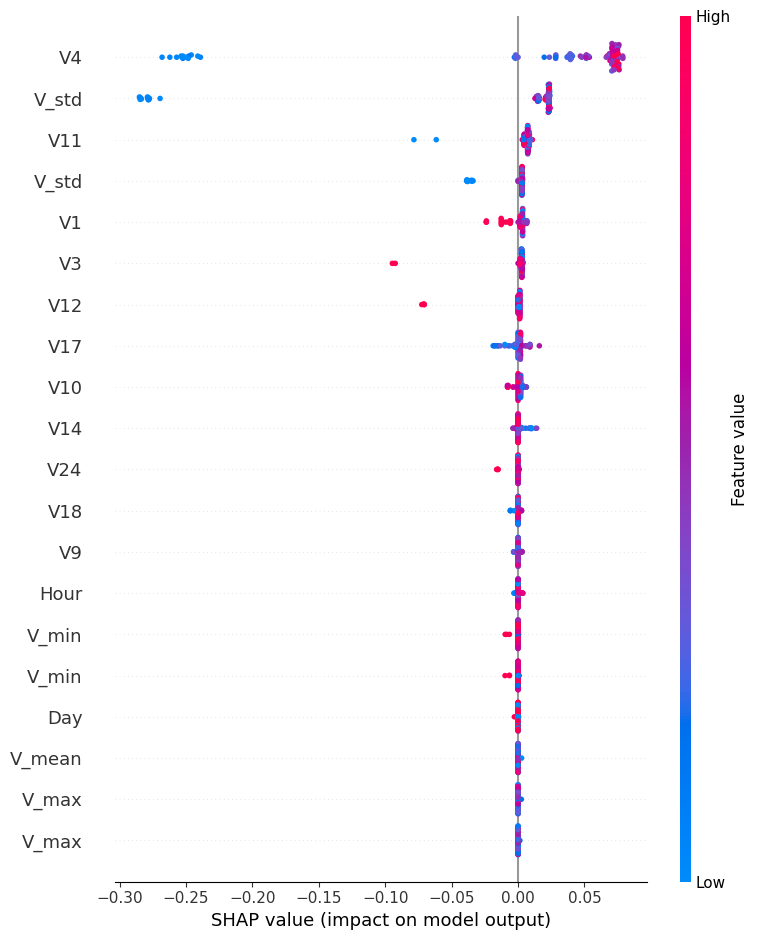

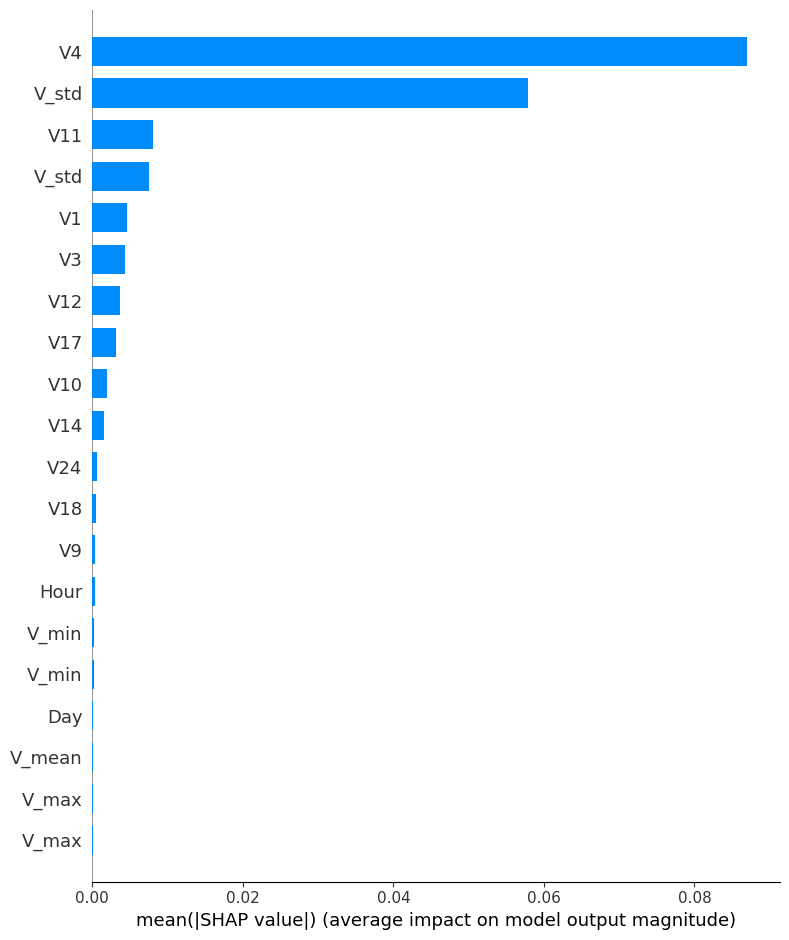

In [13]:
# Cell 9: Global feature importance
print("\n1. GLOBAL FEATURE IMPORTANCE")
print("   (Which features matter most overall?)")
print("="*60)

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_columns, show=False)
plt.tight_layout()
plt.show()

# Bar plot - mean absolute SHAP values
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_columns, plot_type="bar", show=False)
plt.tight_layout()
plt.show()


2. INDIVIDUAL PREDICTION EXPLANATIONS
   (Why did the model make this specific prediction?)

Sample composition:
  Total samples: 100
  Frauds: 0
  Legitimate: 100

⚠️  No frauds in initial sample! Creating balanced sample...

Full test set:
  Total frauds available: 98
  Total legitimate available: 56864

Recalculating SHAP values for 998 samples with 98 frauds...
This may take a minute...


  0%|          | 0/998 [00:00<?, ?it/s]

✓ New balanced sample created!
  Frauds: 98
  Legitimate: 900

Example 1: High-Confidence Fraud Detection
Sample Index: 14
Actual: FRAUD
Predicted Probability: 0.9269
Prediction: FRAUD


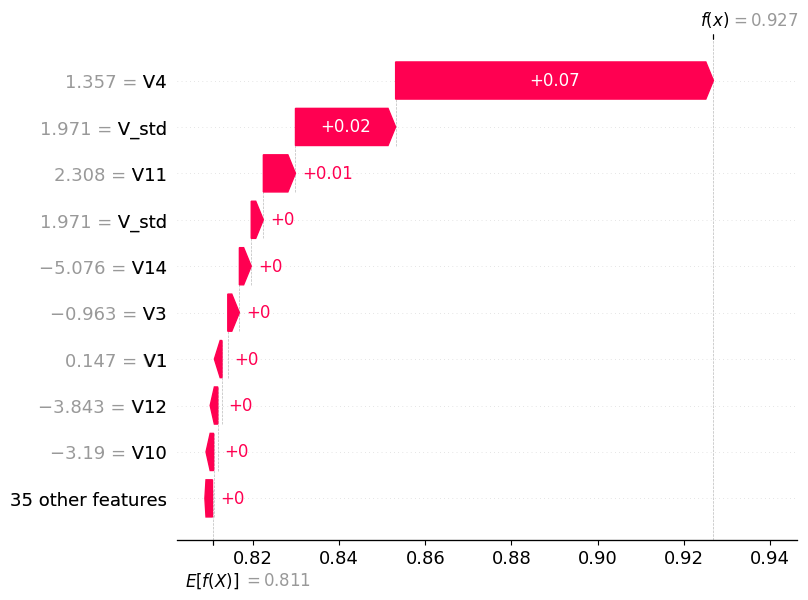


Example 2: High-Confidence Legitimate Transaction
Sample Index: 435
Actual: LEGITIMATE
Predicted Probability: 0.4611
Prediction: LEGITIMATE


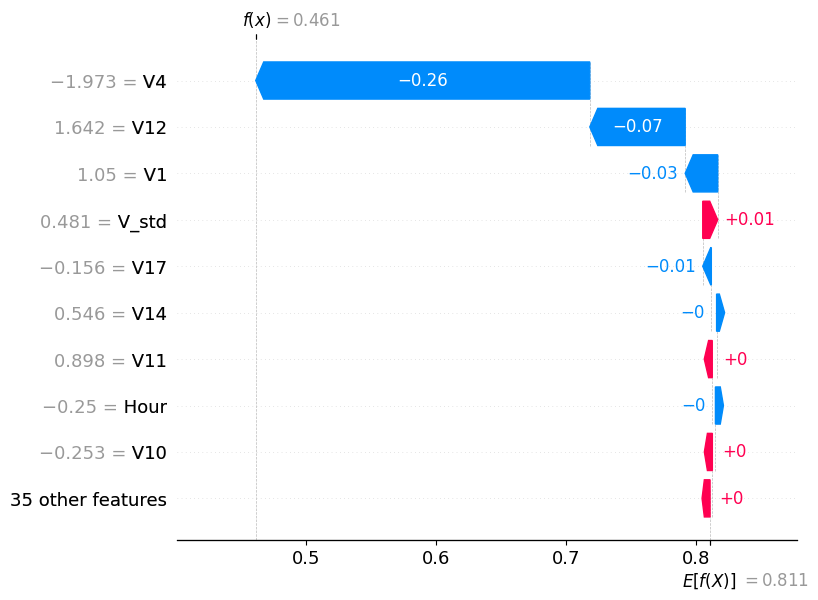


✓ Individual explanations complete!


In [16]:
# Cell 10 (FIXED): Explain individual predictions
print("\n2. INDIVIDUAL PREDICTION EXPLANATIONS")
print("   (Why did the model make this specific prediction?)")
print("="*60)

# First, check if we have frauds in our sample
n_frauds_in_sample = (y_test.values[:sample_size] == 1).sum()
n_legit_in_sample = (y_test.values[:sample_size] == 0).sum()

print(f"\nSample composition:")
print(f"  Total samples: {sample_size}")
print(f"  Frauds: {n_frauds_in_sample}")
print(f"  Legitimate: {n_legit_in_sample}")

if n_frauds_in_sample == 0:
    print("\n⚠️  No frauds in initial sample! Creating balanced sample...")
    
    # Find fraud and legitimate indices in full test set
    fraud_indices = np.where(y_test.values == 1)[0]
    legit_indices = np.where(y_test.values == 0)[0]
    
    print(f"\nFull test set:")
    print(f"  Total frauds available: {len(fraud_indices)}")
    print(f"  Total legitimate available: {len(legit_indices)}")
    
    # Create a balanced sample with frauds and legitimate transactions
    n_frauds_to_sample = min(100, len(fraud_indices))  # Get up to 100 frauds
    n_legit_to_sample = 900  # Get 900 legitimate (if available)
    
    # Randomly sample
    sampled_fraud_indices = np.random.choice(fraud_indices, n_frauds_to_sample, replace=False)
    sampled_legit_indices = np.random.choice(legit_indices, n_legit_to_sample, replace=False)
    
    # Combine and create new sample
    sampled_indices = np.concatenate([sampled_fraud_indices, sampled_legit_indices])
    np.random.shuffle(sampled_indices)  # Shuffle to mix them
    
    # Update sample
    sample_size = len(sampled_indices)
    X_test_sample = X_test_scaled[sampled_indices]
    y_test_sample = y_test.values[sampled_indices]
    
    # Recalculate SHAP values for new sample
    print(f"\nRecalculating SHAP values for {sample_size} samples with {n_frauds_to_sample} frauds...")
    print("This may take a minute...")
    shap_values = explainer.shap_values(X_test_sample)
    
    # Get predictions for new sample
    y_pred_proba_sample = best_model.predict_proba(X_test_sample)[:, 1]
    
    print("✓ New balanced sample created!")
    print(f"  Frauds: {(y_test_sample == 1).sum()}")
    print(f"  Legitimate: {(y_test_sample == 0).sum()}")
else:
    # Use original sample
    y_test_sample = y_test.values[:sample_size]
    y_pred_proba_sample = y_pred_proba[:sample_size]

# Now find fraud and legitimate cases in our sample
fraud_indices_in_sample = np.where(y_test_sample == 1)[0]
legit_indices_in_sample = np.where(y_test_sample == 0)[0]

# Pick specific examples
# For fraud: pick one with HIGH predicted probability (confident fraud detection)
fraud_probs = y_pred_proba_sample[fraud_indices_in_sample]
high_conf_fraud_idx = fraud_indices_in_sample[np.argmax(fraud_probs)]

# For legitimate: pick one with LOW predicted probability (confident legitimate)
legit_probs = y_pred_proba_sample[legit_indices_in_sample]
low_conf_fraud_idx = legit_indices_in_sample[np.argmin(legit_probs)]

print("\n" + "="*60)
print("Example 1: High-Confidence Fraud Detection")
print("="*60)
print(f"Sample Index: {high_conf_fraud_idx}")
print(f"Actual: FRAUD")
print(f"Predicted Probability: {y_pred_proba_sample[high_conf_fraud_idx]:.4f}")
print(f"Prediction: {'FRAUD' if y_pred_proba_sample[high_conf_fraud_idx] > 0.5 else 'LEGITIMATE'}")

# Check if shap_values needs indexing for binary classification
# XGBoost sometimes returns shap_values as a list for binary classification
if isinstance(shap_values, list):
    shap_values_to_use = shap_values[1]  # Use positive class (fraud) SHAP values
    base_value = explainer.expected_value[1]
else:
    shap_values_to_use = shap_values
    base_value = explainer.expected_value

# Waterfall plot for fraud
try:
    shap.waterfall_plot(shap.Explanation(
        values=shap_values_to_use[high_conf_fraud_idx],
        base_values=base_value,
        data=X_test_sample[high_conf_fraud_idx],
        feature_names=feature_columns
    ))
except Exception as e:
    print(f"Waterfall plot error: {e}")
    print("Showing simplified explanation instead:")
    
    # Simplified explanation
    shap_vals = shap_values_to_use[high_conf_fraud_idx]
    feature_vals = X_test_sample[high_conf_fraud_idx]
    
    # Get top contributing features
    contrib_df = pd.DataFrame({
        'feature': feature_columns,
        'shap_value': shap_vals,
        'feature_value': feature_vals
    })
    contrib_df['abs_shap'] = np.abs(contrib_df['shap_value'])
    contrib_df = contrib_df.sort_values('abs_shap', ascending=False)
    
    print("\nTop 10 Contributing Features:")
    for idx, row in contrib_df.head(10).iterrows():
        direction = "increased" if row['shap_value'] > 0 else "decreased"
        print(f"  {row['feature']}: {direction} fraud probability by {abs(row['shap_value']):.4f}")
        print(f"    (feature value: {row['feature_value']:.4f})")

print("\n" + "="*60)
print("Example 2: High-Confidence Legitimate Transaction")
print("="*60)
print(f"Sample Index: {low_conf_fraud_idx}")
print(f"Actual: LEGITIMATE")
print(f"Predicted Probability: {y_pred_proba_sample[low_conf_fraud_idx]:.4f}")
print(f"Prediction: {'FRAUD' if y_pred_proba_sample[low_conf_fraud_idx] > 0.5 else 'LEGITIMATE'}")

# Waterfall plot for legitimate
try:
    shap.waterfall_plot(shap.Explanation(
        values=shap_values_to_use[low_conf_fraud_idx],
        base_values=base_value,
        data=X_test_sample[low_conf_fraud_idx],
        feature_names=feature_columns
    ))
except Exception as e:
    print(f"Waterfall plot error: {e}")
    print("Showing simplified explanation instead:")
    
    # Simplified explanation
    shap_vals = shap_values_to_use[low_conf_fraud_idx]
    feature_vals = X_test_sample[low_conf_fraud_idx]
    
    # Get top contributing features
    contrib_df = pd.DataFrame({
        'feature': feature_columns,
        'shap_value': shap_vals,
        'feature_value': feature_vals
    })
    contrib_df['abs_shap'] = np.abs(contrib_df['shap_value'])
    contrib_df = contrib_df.sort_values('abs_shap', ascending=False)
    
    print("\nTop 10 Contributing Features:")
    for idx, row in contrib_df.head(10).iterrows():
        direction = "increased" if row['shap_value'] > 0 else "decreased"
        print(f"  {row['feature']}: {direction} fraud probability by {abs(row['shap_value']):.4f}")
        print(f"    (feature value: {row['feature_value']:.4f})")

print("\n✓ Individual explanations complete!")
# ```

# ---

# ## 📊 **Understanding What This Fixed Code Does**

# ### **Problem Diagnosis:**
# 1. **Original issue**: First 1000 samples might not contain any frauds (fraud rate is only 0.17%)
# 2. **Solution**: Creates a balanced sample ensuring both fraud and legitimate cases

# ### **Step-by-Step:**
# ```
# Step 1: Check initial sample
#   └─> If no frauds → Create new balanced sample

# Step 2: Sample selection strategy
#   ├─> Get 100 fraud cases (or all available)
#   └─> Get 900 legitimate cases

# Step 3: Recalculate SHAP for new sample
#   └─> Ensures we can explain both types

# Step 4: Pick best examples
#   ├─> High-confidence fraud (high probability)
#   └─> High-confidence legitimate (low probability)

# Step 5: Display waterfall plots
#   └─> Shows feature contributions

In [18]:
# Cell 11 (FIXED): Force plot for interactive exploration
print("\n3. INTERACTIVE FORCE PLOT")
print("="*60)

# First, ensure we have the indices from previous analysis
# Find fraud and legitimate cases in our sample
if 'y_test_sample' in dir():
    # Use the balanced sample from Cell 10
    fraud_indices_in_sample = np.where(y_test_sample == 1)[0]
    legit_indices_in_sample = np.where(y_test_sample == 0)[0]
    
    # Pick examples (same logic as Cell 10)
    if 'y_pred_proba_sample' in dir():
        fraud_probs = y_pred_proba_sample[fraud_indices_in_sample]
        legit_probs = y_pred_proba_sample[legit_indices_in_sample]
    else:
        # Recalculate if needed
        y_pred_proba_sample = best_model.predict_proba(X_test_sample)[:, 1]
        fraud_probs = y_pred_proba_sample[fraud_indices_in_sample]
        legit_probs = y_pred_proba_sample[legit_indices_in_sample]
    
    fraud_idx = fraud_indices_in_sample[np.argmax(fraud_probs)]
    legit_idx = legit_indices_in_sample[np.argmin(legit_probs)]
else:
    # Fallback: use original sample
    y_test_sample = y_test.values[:sample_size]
    y_pred_proba_sample = y_pred_proba[:sample_size]
    
    fraud_indices_in_sample = np.where(y_test_sample == 1)[0]
    legit_indices_in_sample = np.where(y_test_sample == 0)[0]
    
    if len(fraud_indices_in_sample) > 0:
        fraud_probs = y_pred_proba_sample[fraud_indices_in_sample]
        fraud_idx = fraud_indices_in_sample[np.argmax(fraud_probs)]
    else:
        print("⚠️  No frauds in sample! Creating balanced sample...")
        # Same balanced sampling logic as Cell 10
        fraud_indices_full = np.where(y_test.values == 1)[0]
        legit_indices_full = np.where(y_test.values == 0)[0]
        
        sampled_fraud = np.random.choice(fraud_indices_full, 100, replace=False)
        sampled_legit = np.random.choice(legit_indices_full, 900, replace=False)
        sampled_indices = np.concatenate([sampled_fraud, sampled_legit])
        
        X_test_sample = X_test_scaled[sampled_indices]
        y_test_sample = y_test.values[sampled_indices]
        y_pred_proba_sample = best_model.predict_proba(X_test_sample)[:, 1]
        
        # Recalculate SHAP
        shap_values = explainer.shap_values(X_test_sample)
        
        fraud_indices_in_sample = np.where(y_test_sample == 1)[0]
        fraud_probs = y_pred_proba_sample[fraud_indices_in_sample]
        fraud_idx = fraud_indices_in_sample[np.argmax(fraud_probs)]
    
    if len(legit_indices_in_sample) > 0:
        legit_probs = y_pred_proba_sample[legit_indices_in_sample]
        legit_idx = legit_indices_in_sample[np.argmin(legit_probs)]

print(f"\nSelected examples:")
print(f"  Fraud index: {fraud_idx} (probability: {y_pred_proba_sample[fraud_idx]:.4f})")
print(f"  Legitimate index: {legit_idx} (probability: {y_pred_proba_sample[legit_idx]:.4f})")

# Handle different SHAP value formats (list vs array)
if isinstance(shap_values, list):
    shap_values_to_use = shap_values[1]  # Positive class for binary classification
    base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value
else:
    shap_values_to_use = shap_values
    base_value = explainer.expected_value

# Initialize JavaScript for Jupyter
print("\nInitializing interactive visualization...")
try:
    shap.initjs()
    
    # Create force plot for fraud case
    print("\n📊 Force Plot for FRAUD Transaction:")
    display(shap.force_plot(
        base_value,
        shap_values_to_use[fraud_idx],
        X_test_sample[fraud_idx],
        feature_names=feature_columns,
        matplotlib=False  # Use JavaScript version for interactivity
    ))
    
    print("\n📊 Force Plot for LEGITIMATE Transaction:")
    display(shap.force_plot(
        base_value,
        shap_values_to_use[legit_idx],
        X_test_sample[legit_idx],
        feature_names=feature_columns,
        matplotlib=False
    ))
    
except Exception as e:
    print(f"\n⚠️  Interactive force plot failed: {e}")
    print("Showing matplotlib version instead...\n")
    
    # Fallback to matplotlib version
    print("📊 Force Plot for FRAUD Transaction:")
    shap.force_plot(
        base_value,
        shap_values_to_use[fraud_idx],
        X_test_sample[fraud_idx],
        feature_names=feature_columns,
        matplotlib=True,
        show=True
    )
    
    print("\n📊 Force Plot for LEGITIMATE Transaction:")
    shap.force_plot(
        base_value,
        shap_values_to_use[legit_idx],
        X_test_sample[legit_idx],
        feature_names=feature_columns,
        matplotlib=True,
        show=True
    )

# Bonus: Create force plot for multiple transactions
print("\n" + "="*60)
print("4. FORCE PLOT FOR MULTIPLE TRANSACTIONS")
print("="*60)

try:
    # Select a few fraud and legitimate transactions
    n_examples = min(20, len(fraud_indices_in_sample), len(legit_indices_in_sample))
    
    fraud_sample_indices = fraud_indices_in_sample[:n_examples]
    legit_sample_indices = legit_indices_in_sample[:n_examples]
    
    combined_indices = np.concatenate([fraud_sample_indices, legit_sample_indices])
    
    print(f"\nShowing {len(combined_indices)} transactions ({n_examples} fraud, {n_examples} legitimate)")
    
    display(shap.force_plot(
        base_value,
        shap_values_to_use[combined_indices],
        X_test_sample[combined_indices],
        feature_names=feature_columns
    ))
    
except Exception as e:
    print(f"Multiple transaction plot failed: {e}")
    print("Skipping multi-transaction visualization")

print("\n✓ Interactive visualizations complete!")


3. INTERACTIVE FORCE PLOT

Selected examples:
  Fraud index: 14 (probability: 0.9269)
  Legitimate index: 435 (probability: 0.4611)

Initializing interactive visualization...



📊 Force Plot for FRAUD Transaction:



📊 Force Plot for LEGITIMATE Transaction:



4. FORCE PLOT FOR MULTIPLE TRANSACTIONS

Showing 40 transactions (20 fraud, 20 legitimate)



✓ Interactive visualizations complete!


In [19]:
# Cell 12: Save the final optimized model
import pickle
import json
from datetime import datetime

print("="*60)
print("SAVING OPTIMIZED MODEL")
print("="*60)

# Create models directory
import os
os.makedirs('../models/optimized', exist_ok=True)

# Save model
model_path = '../models/optimized/xgboost_tuned.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f"✓ Model saved: {model_path}")

# Save scaler
scaler_path = '../models/optimized/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler saved: {scaler_path}")

# Save feature names
features_path = '../models/optimized/feature_names.pkl'
with open(features_path, 'wb') as f:
    pickle.dump(feature_columns, f)
print(f"✓ Feature names saved: {features_path}")

# Save best threshold
threshold_info = {
    'best_f1_threshold': float(results_df.loc[best_f1_idx, 'threshold']),
    'high_recall_threshold': float(high_recall_thresh['threshold']),
    'default_threshold': 0.5,
    'recommendation': 'Use high_recall_threshold for production (prioritize catching fraud)'
}

threshold_path = '../models/optimized/thresholds.json'
with open(threshold_path, 'w') as f:
    json.dump(threshold_info, f, indent=4)
print(f"✓ Thresholds saved: {threshold_path}")

# Save model metadata
metadata = {
    'model_type': 'XGBoost',
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'best_params': grid_search.best_params_,  # or random_search.best_params_
    'cv_recall': float(cv_results['test_recall'].mean()),
    'test_recall': float(recall),
    'test_precision': float(precision),
    'test_f1': float(f1),
    'test_roc_auc': float(roc_auc),
    'n_features': len(feature_columns),
    'training_samples': len(X_train_balanced),
    'test_samples': len(X_test)
}

metadata_path = '../models/optimized/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"✓ Metadata saved: {metadata_path}")

print("\n" + "="*60)
print("ALL FILES SAVED SUCCESSFULLY!")
print("="*60)
# ```

# ---

# ## 🚀 **LESSON 3.6: Build a Simple API (FastAPI)**

# ### **What is an API?**

# **API** = Application Programming Interface

# **Analogy:** Like a restaurant:
# - **You (client)**: Make a request ("I want pasta")
# - **Waiter (API)**: Takes your order to the kitchen
# - **Kitchen (model)**: Prepares the food
# - **Waiter (API)**: Brings back the result

# **For our fraud detection:**
# ```
# Transaction data → API → Model → Fraud/Legitimate

SAVING OPTIMIZED MODEL
✓ Model saved: ../models/optimized/xgboost_tuned.pkl
✓ Scaler saved: ../models/optimized/scaler.pkl
✓ Feature names saved: ../models/optimized/feature_names.pkl
✓ Thresholds saved: ../models/optimized/thresholds.json
✓ Metadata saved: ../models/optimized/model_metadata.json

ALL FILES SAVED SUCCESSFULLY!
